![Logo del Instituto](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/logoitqv1.jpg)

# EXTRACCIÓN DE CARACTERISTICAS PARA LA DETECCIÓN DE TUMORES CEREBRALES MEDIANTE ANALISIS EXPLORATORIO DE DATOS Y LA METODOLOGIA CRISP-DM 

![Logo de Python](https://raw.githubusercontent.com/Alelop-Itu/machine12026nocturno/refs/heads/main/img/python_logo.png)

* Integrantes: Cinthya Cuñez, Alejandra López, Judith Piedra, Emily Salvador y Cristhian Zumárraga
* Fecha: **22-07-2026**
* Repositorio: [Link del repositorio de Github](https://github.com/Alelop-Itu/TUMORES-CEREBRALES.git)

## PASO 2: Comprensión de los datos. 

Librerías necesarias para la gestión del enforma y comunicación con Kaggle.
* kaggle: Librerpia utilizada para la descarga programática y gestión de conjuntos de datos desde kaggle
* Módulo estándar de python utilizado para interactuar con el sistema operativo y gestionar las rutas de archivos del proyecto.


In [1]:
import kagglehub
import os

C:\Users\ALEJANDRA\anaconda3\envs\machinelearning2026nocturno\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Descarga de los datos**

Se realiza la conexión directa con el repositorio en la nube mediante el enlace de kaggle (https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset ) , asegurando la replicabilidad del proceso de obtención de datos mediante código python conforme a la metodología CRISP-DM.

In [2]:
# Descargar el dataset mediante código

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("El dataset ha sido descargado en:", path)

El dataset ha sido descargado en: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2


**Inspección del dataset descargado**

Se utiliza *os.walk* para recorrer el sistema de archivos para identificar la jerarquía de directorios y confirmar la distribución de los archivos de imagen.

**Nota**: Es un paso fundamental para validar la integridad de la estructura antes del análisis exploratorio.

In [3]:
# Listar las carpetas principales para verificar la estructura

print("\nEstructura de carpetas:")

for root, dirs, files in os.walk(path):
    print(f"Carpeta: {root}, Archivos: {len(files)}")


Estructura de carpetas:
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2, Archivos: 0
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing, Archivos: 0
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing\glioma, Archivos: 400
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing\meningioma, Archivos: 400
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing\notumor, Archivos: 400
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Testing\pituitary, Archivos: 400
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\datasets\masoudnickparvar\brain-tumor-mri-dataset\versions\2\Training, Archivos: 0
Carpeta: C:\Users\ALEJANDRA\.cache\kagglehub\data

**Exploración de los datos**

Descarga de librerías para procesamiento digital de las imágenes y análisis de datos
* pandas: Biblioteca usada para la manipulación y estructuración de datos en formato tabular, necesaria para organizar la información en un dataset.
* cv2(OpenCV): Herramienta para la carga y el procesamiento avanzado de imágenes, utilizada para extraer propiedades técnicas como la resolución de las resonancias magnéticas.
* os: Módulo utilizado para garantizar la compatibilidad de rutas de archivos en el sistema operativo, permitiendo una navegación robusta a través de los directorios del dataset.


In [4]:
import pandas as pd
import cv2
import os

* Función *explorar_dataset_profundo*: Recorreo de forma recursiva la jerarquía del dataset, accediendo a los conjuntos de **Training** y **Testing**.
* Extracción de medatados: De cada imagen encontrada, se captura la categoría diagnóstica, resolución (ancho*alto) y guarda la información en el dataframe de pandas para facilitar análisis posteriores.
  
  -Número total de imágenes
  
  -Número de personas
  
  -Distribución de imágenes por persona
  
  -Resolución de las imágenes
  
  -Etiquetas disponibles
  
  -Tamaño del conjunto de datos

In [13]:
# Definir la ruta del dataset (ajusta 'path' a la variable resultante del paso anterior)
data_dir = path

def explorar_dataset_profundo(base_path):
    datos = []
    # Recorremos el dataset principal (Training y Testing)
    for carpeta_nivel1 in os.listdir(base_path):
        ruta_nivel1 = os.path.join(base_path, carpeta_nivel1)
        
        if os.path.isdir(ruta_nivel1):
            # Recorremos las categorías dentro de cada carpeta
            for categoria in os.listdir(ruta_nivel1):
                ruta_categoria = os.path.join(ruta_nivel1, categoria)
                
                if os.path.isdir(ruta_categoria):
                    for img_name in os.listdir(ruta_categoria):
                        img_path = os.path.join(ruta_categoria, img_name)
                        img = cv2.imread(img_path)
                        if img is not None:
                            datos.append({
                                'set': carpeta_nivel1, # Training o Testing
                                'categoria': categoria, # glioma, meningioma, etc.
                                'res_ancho': img.shape[1], #ancho
                                'res_alto': img.shape[0] #alto
                            })
    return pd.DataFrame(datos)

**Aclaraciones requeridas por el proyecto**

El dataset es anónimo: No se cuenta con datos de personas ni distribución por paciente para preservar la privacidad médica. Por tanto, no se cuenta con la información de los pacientes ni se puede extraer la distribución de imágenes por persona.

In [15]:
# Crear tabla de resumen con conteo y resoluciones
resumen = df_info.groupby(['set', 'categoria']).agg({
    'categoria': 'count',
    'res_ancho': 'mean',
    'res_alto': 'mean'
}).rename(columns={'categoria': 'cantidad', 'res_ancho': 'ancho_prom', 'res_alto': 'alto_prom'})

# Mostrar como tabla formateada
print("Resumen del Dataset:")
display(resumen)

#Total de imágenes encontradas
print(f"\nTotal de imágenes encontradas: {len(df_info)}")

# Etiquetas disponibles
print(f"Etiquetas (clases) detectadas: {list(df_info['categoria'].unique())}")

Resumen del Dataset:


cantidad  ancho_prom   alto_prom
set      categoria                                   
Testing  glioma           400  487.415000  492.127500
         meningioma       400  456.347500  461.600000
         notumor          400  289.617500  291.897500
         pituitary        400  506.880000  506.880000
Training glioma          1400  512.000000  512.000000
         meningioma      1400  495.413571  497.037857
         notumor         1400  313.550714  327.355000
         pituitary       1400  513.090714  512.658571


Total de imágenes encontradas: 7200
Etiquetas (clases) detectadas: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Visualización de una muestra representativa de imágenes del dataset para comprender su variabilidad**

* matplotlib.pyplot: Se usa para gestionar la disposición y renderizado de las gráficas.
* Mediante un bucle for, el código filtra  el DataFrame para extraer una muestra representativa (la primera imagen) de cada categoría
* Se reconstruye la ruta física de cada archivo, se carga mediante OpenCV (cv2.imread) y se realiza una conversión de color (cv2.cvtColor) de formato BGR a RGB, debido a que OpenCV y Matplotlib utilizan estándares de color distintos.
* Visualización en subgráficos: Se organiza la salida en una única fila (plt.subplot), mostrando cada imagen con su respectiva etiqueta de categoría y eliminando los ejes (plt.axis('off')) para una mejorar la visualización.

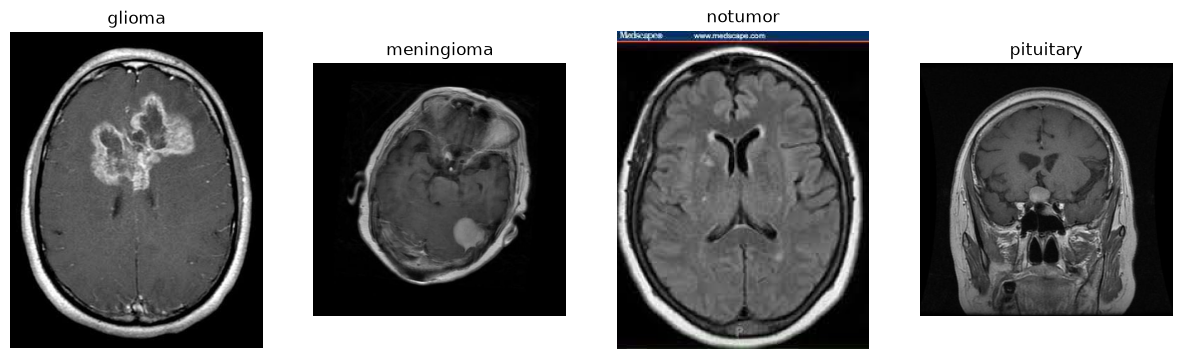

In [16]:
import matplotlib.pyplot as plt

# Visualizar una imagen por categoría
plt.figure(figsize=(15, 5))
categorias = df_info['categoria'].unique()

for i, cat in enumerate(categorias):
    
    # Buscar una imagen de esa categoría
    ruta_img = df_info[df_info['categoria'] == cat].iloc[0]
    
    # Reconstruir la ruta completa
    img = cv2.imread(os.path.join(path, ruta_img['set'], cat, os.listdir(os.path.join(path, ruta_img['set'], cat))[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(categorias), i+1)
    plt.imshow(img)
    plt.title(cat)
    plt.axis('off')
    
plt.show()